In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
train = pd.read_csv("../data/train.csv", converters={"bbox": ast.literal_eval})
test = pd.read_csv("../data/test.csv",  converters={"bbox": ast.literal_eval})

In [3]:
train

,row_id,image_id,width,height,bbox,class_id
0,train_00000001_0000,00000001.jpg,1920,1080,"[967.5, 331.5, 463.0, 447.0]",3
1,train_00000001_0001,00000001.jpg,1920,1080,"[724.5, 336.5, 324.0, 412.0]",3
2,train_00000001_0002,00000001.jpg,1920,1080,"[430.5, 390.5, 249.0, 457.0]",4
3,train_00000001_0003,00000001.jpg,1920,1080,"[1199.0, 5.5, 208.0, 282.0]",3
4,train_00000001_0004,00000001.jpg,1920,1080,"[980.0, 5.5, 273.0, 285.0]",3
...,...,...,...,...,...,...
16057,train_00002164_0005,00002164.jpg,1280,720,"[594.4, 566.5, 390.0, 146.0]",4
16058,train_00002164_0006,00002164.jpg,1280,720,"[792.5, 1.0, 147.0, 321.0]",3
16059,train_00002164_0007,00002164.jpg,1280,720,"[187.0, 132.0, 168.0, 255.0]",3
16060,train_00002164_0008,00002164.jpg,1280,720,"[55.0, 180.5, 107.0, 198.0]",3


In [4]:
x = [value["bbox"][0]* 1280 / value["width"] for i, value in train.iterrows()]
y = [value["bbox"][1]* 720 / value["height"] for i, value in train.iterrows()]


<Axes: >

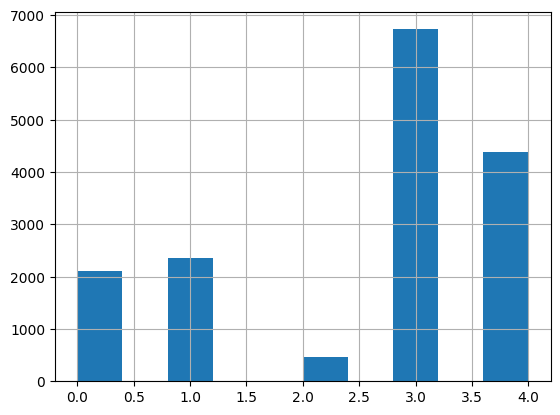

In [5]:
train["class_id"].hist()

(array([[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  11.,  15.,   6.,
           8.,  14.,  12.,  15.,  20.,  23.,  33.,  38.,  21.,  21.,   9.,
           9.,  14.,  13.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   1.,   0.,   7.,  22.,  33.,  35.,  34.,
          13.,   9.,   8.,   6.,   8.,  13.,  32.,  12.,  10.,   6.,  14.,
           8.,  22.,  28.,   1.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,  12.,  28.,  47.,  28.,  60.,  33.,  22.,
          30.,  14.,  17.,  30.,  14.,  11.,  13.,   5.,  11.,   4.,   4.,
           2.,  13.,  31.,   2.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   1.,   3.,  39.,  58.,  81.,  80.,  54.,  27.,  22.,
          33.,  32.,  32.,  37.,  36.,  40.,  26.,  24.,  13.,  11.,  16.,
           2.,   7.,  14.,   2.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   3.,   4.,  13.,  21., 144.,  50.,  21.,  20.,  17.,
          18.,  26.,  68.,   9.,  30.,  54.,  25.,  26.,  33.,  34.,  21.,
          15.,   7

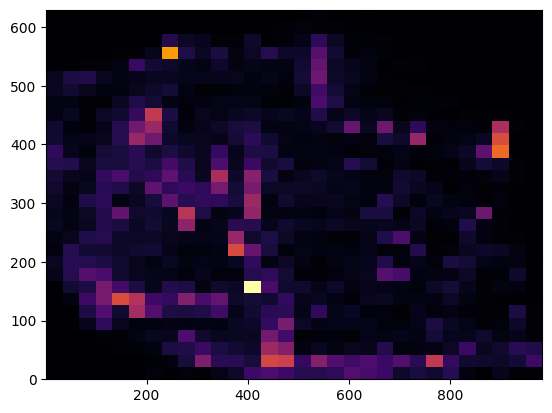

In [6]:
plt.hist2d(x, y, bins=30, cmap="inferno")

In [7]:
newx = np.array(x)
newy = np.array(y)

In [8]:
newx[train["class_id"] == 0]

array([377.        , 432.4       , 432.66666667, ..., 576.        ,
       470.        , 455.        ])

(array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  4.,  0.,  0.,  0.,
          0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1., 10.,  1.,  0.,
          0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,
          0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  1.,  8.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  1.,  7., 14.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0., 20.,  1.,  1.,  0.,  0.,  0.,  0.,
          2.,  2.,  4.,  4.,  5.,  2.,  1.,  3.,  2.,  1.,  7.,  3.,  6.,
          0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  1.,
          3.,  3.,  4.,  8., 17.,  9., 23.,  8.,  3.,  1.,  1.,  0.,  0.,
          0.,  0.,  0.,  0.],
        [ 0.,  0.,  3.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,
          5.,  1., 14.,  4.,  0.,  4

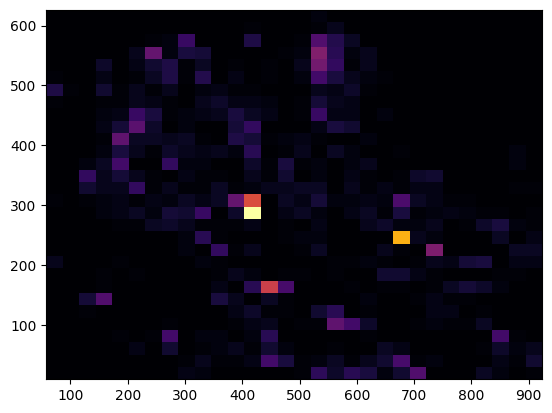

In [9]:
plt.hist2d(newx[train["class_id"] == 0], newy[train["class_id"] == 0], bins=30, cmap="inferno")

(array([[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   2.,   0.,   0.,   1.,
           3.,   2.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  13.,   4.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   7.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   2.,   5.,   0.,   0.,   0.,
           3.,   4.,   4.,   1.,   0.,   0.,   1.,   3.,   2.,   0.,   0.,
           0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   4.,   4.,  10.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   1.,   1.,   3.,
           0.,   0.,   1.,   1.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
           0.,   1.,   1.,   0.,   0.,   1.,   4.,   4.,  10.,  98.,  39.,
          11.,   5

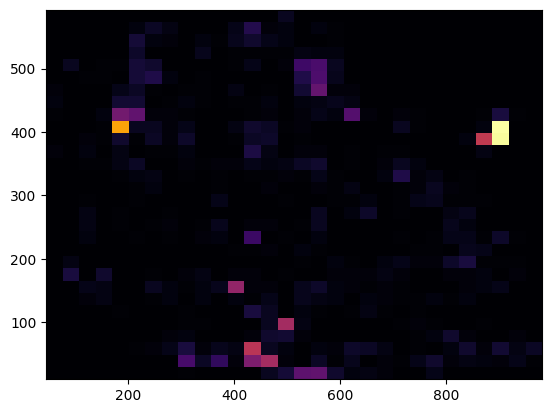

In [10]:
plt.hist2d(newx[train["class_id"] == 1], newy[train["class_id"] == 1], bins=30, cmap="inferno")

(array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  0.,  1.,
          0.,  0.,  0.,  0.,  0.,  1.,  0.,  1.,  0.,  1.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,  1.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,  0.,  0.,  1.,
          0.,  0.,  0.,  1.,  2.,  1.,  0.,  1.,  1.,  0.,  0.,  0.,  0.,
          0.,  1.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  3.,  4.,  3.,  3.,  2.,  0.,  0.,  0.,  2.,
          0.,  0.,  1.,  4.,  2.,  1.,  1.,  1.,  1.,  1.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  2.,  1.,  2.,  2.,  0.,  1.,  2.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.,  2.,  1.,  0.,  1.,  0.,
          0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  1.,  0.,  2.,  1

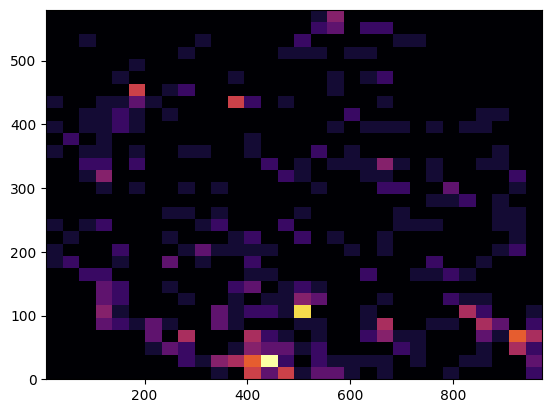

In [11]:
plt.hist2d(newx[train["class_id"] == 2], newy[train["class_id"] == 2], bins=30, cmap="inferno")

(array([[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  11.,  14.,   6.,
           7.,  14.,  12.,  15.,  20.,  21.,  32.,  38.,  21.,  20.,   9.,
           9.,  14.,  13.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   1.,   0.,   7.,  22.,  30.,  23.,  13.,
          11.,   8.,   8.,   6.,   4.,   9.,   8.,   8.,   6.,   5.,   7.,
           7.,   9.,  12.,   1.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,  11.,  27.,  45.,  27.,  31.,  29.,  21.,
          27.,  12.,  17.,  28.,  13.,  10.,   6.,   1.,   8.,   3.,   4.,
           1.,   4.,   2.,   1.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   1.,   3.,  35.,  57.,  62.,  51.,  42.,  26.,  21.,
          22.,  12.,  17.,  32.,  34.,  29.,  22.,  20.,   8.,   8.,  10.,
           2.,   2.,   5.,   1.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   3.,   3.,   8.,  13.,  71.,  16.,  14.,  17.,  17.,
          15.,  10.,  10.,   3.,  18.,  10.,   8.,  10.,  19.,  17.,  17.,
          10.,   1

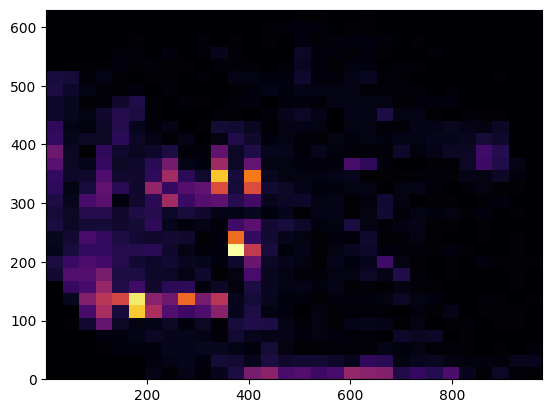

In [12]:
plt.hist2d(newx[train["class_id"] == 3], newy[train["class_id"] == 3], bins=30, cmap="inferno")


(array([[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,  13.,
           6.,   1.,   1.,   0.,   0.,   2.,   7.,  21.,   3.,   2.,   0.,
           2.,   1.,   5.,  15.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.,   4.,   7.,
           3.,   0.,   0.,   0.,   0.,   3.,   0.,   7.,   0.,   3.,   1.,
           0.,   0.,   3.,  27.,   2.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   8.,   8.,   7.,   0.,
           0.,   2.,   3.,   0.,   1.,   0.,   0.,   0.,   1.,   2.,   1.,
           4.,   0.,   3.,   4.,   2.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   2.,   0.,  31.,  51.,   8.,   3.,   1.,
           4.,  13.,  82.,   6.,   6.,   1.,  27.,   8.,   7.,   6.,   5.,
           2.,   2.,   1.,   6.,   6.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   2.,   1.,   0.,   0.,   1.,   0.,   0.,   2.,
           1.,   3.,   2.,   1.,   2.,   3.,   8.,   7.,  14.,  15.,  18.,
           7.,   6

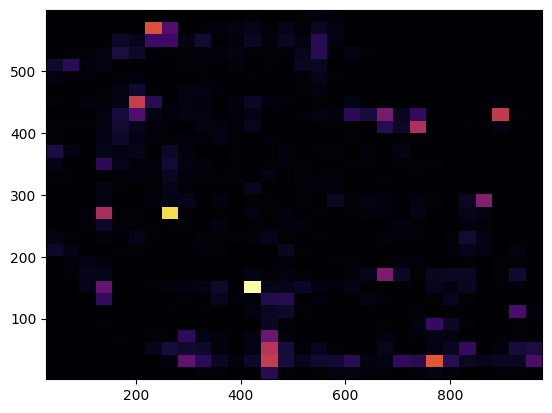

In [13]:
plt.hist2d(newx[train["class_id"] == 4], newy[train["class_id"] == 4], bins=30, cmap="inferno")


# Split train, test, validation data

In [15]:
train_df, temp_df = train_test_split(train, test_size=0.3, random_state=42, stratify=train["class_id"])

In [18]:
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["class_id"])

In [20]:
train_df.to_csv("../data/split/train.csv")
test_df.to_csv("../data/split/test.csv")
val_df.to_csv("../data/split/val.csv")

In [22]:
val_df["class_id"].value_counts()

class_id
3    1009
4     658
1     354
0     317
2      71
Name: count, dtype: int64